# La Jolla Cove Species Identification — Quantization-Aware Training (QAT)

Same pipeline as `species_identification.ipynb` (DINOv2 ViT-B/14 + linear head), but the **classification head** is trained with **quantization-aware training**: fake-quantized `Linear` (and stubs) so that after `convert` the head matches **static INT8** deployment better than plain PTQ.

- Backbone stays **float** (frozen by default); only the head is QAT — the `.pth` checkpoint is **not** FPU-free.
- **True int8-only / no-FPU inference** targets **`outputs_qat/tflite_int8/model_int8.tflite`** (onnx2tf full-integer). Run `python verify_tflite_full_integer.py ...` after export; large ViT graphs may still contain float MatMul fallbacks — if verification fails strict checks, use **`qat_efficientnet_lite.ipynb`** (CNN + TF QAT) for a quantization-friendly full-integer `.tflite`.
- **AMP is disabled** during QAT to avoid interactions with fake-quant observers.
- Artifacts go to **`outputs_qat/`** so they do not overwrite the float run in `outputs/`.

## 1. Setup and Imports

In [2]:
import os
import json
import copy
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
from PIL import Image

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    print("MPS (Apple Silicon) available")

PyTorch version: 2.6.0+cu118
Torchvision version: 0.21.0+cu118
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4070 Laptop GPU


### Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs_qat")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Model ──────────────────────────────────────────────────────────────────────
MODEL_NAME = "dinov2_vitb14"
IMAGE_SIZE = 224
FREEZE_BACKBONE = True

# ── Training ───────────────────────────────────────────────────────────────────
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
LR_FINETUNE = 1e-5
NUM_EPOCHS = 30
EARLY_STOP_PATIENCE = 5

# QAT: keep full precision in the training loop (no AMP with fake-quant)
USE_AMP = False

# ── Hardware ───────────────────────────────────────────────────────────────────
NUM_WORKERS = 4
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
print(f"AMP: {USE_AMP} (disabled for QAT)")
print(f"Backbone frozen: {FREEZE_BACKBONE}")
print(f"Effective LR: {LEARNING_RATE if FREEZE_BACKBONE else LR_FINETUNE}")

Device: cuda
AMP: False (disabled for QAT)
Backbone frozen: True
Effective LR: 0.001


## 2. Dataset Loading and Inspection

In [9]:
_inspect_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_dataset_raw = datasets.ImageFolder(DATA_DIR / "train", transform=_inspect_transform)
val_dataset_raw = datasets.ImageFolder(DATA_DIR / "val", transform=_inspect_transform)
test_dataset_raw = datasets.ImageFolder(DATA_DIR / "test", transform=_inspect_transform)

class_names = train_dataset_raw.classes
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}\n")

for split_name, ds in [("Train", train_dataset_raw), ("Val", val_dataset_raw), ("Test", test_dataset_raw)]:
    targets = [s[1] for s in ds.samples]
    counts = Counter(targets)
    print(f"  {split_name}: {len(ds)} images")
    for idx in sorted(counts):
        print(f"    {ds.classes[idx]:>30s}: {counts[idx]}")
    print()

Number of classes: 88
Class names: ['Actitis_macularius', 'Allograpta_obliqua', 'Apis_mellifera', 'Arenaria_melanocephala', 'Argyranthemum_foeniculaceum', 'Artemisia_californica', 'Bombus_vosnesenskii', 'Bubo_virginianus', 'Buteo_lineatus', 'Calidris_minutilla', 'Calypte_anna', 'Canis_latrans', 'Carpobrotus_edulis', 'Columba_livia_domestica', 'Corvus_corax', 'Cotinis_mutabilis', 'Cycloneda_sanguinea', 'Danaus_plexippus', 'Dione_vanillae', 'Diplacus_puniceus', 'Echium_candicans', 'Egretta_thula', 'Encelia_californica', 'Eriogonum_fasciculatum', 'Euphorbia_maculata', 'Euphorbia_peplus', 'Euphorbia_serpens', 'Haematopus_bachmani', 'Haematopus_palliatus_x_bachmani', 'Haemorhous_mexicanus', 'Harmonia_axyridis', 'Heteromeles_arbutifolia', 'Hydroprogne_caspia', 'Hylephila_phyleus', 'Hyles_lineata', 'Isocoma_menziesii', 'Junco_hyemalis', 'Laetiporus_gilbertsonii', 'Larus_californicus', 'Larus_delawarensis', 'Larus_heermanni', 'Larus_occidentalis', 'Leiothlypis_celata', 'Limonium_perezii', 'Mar

### Sample images

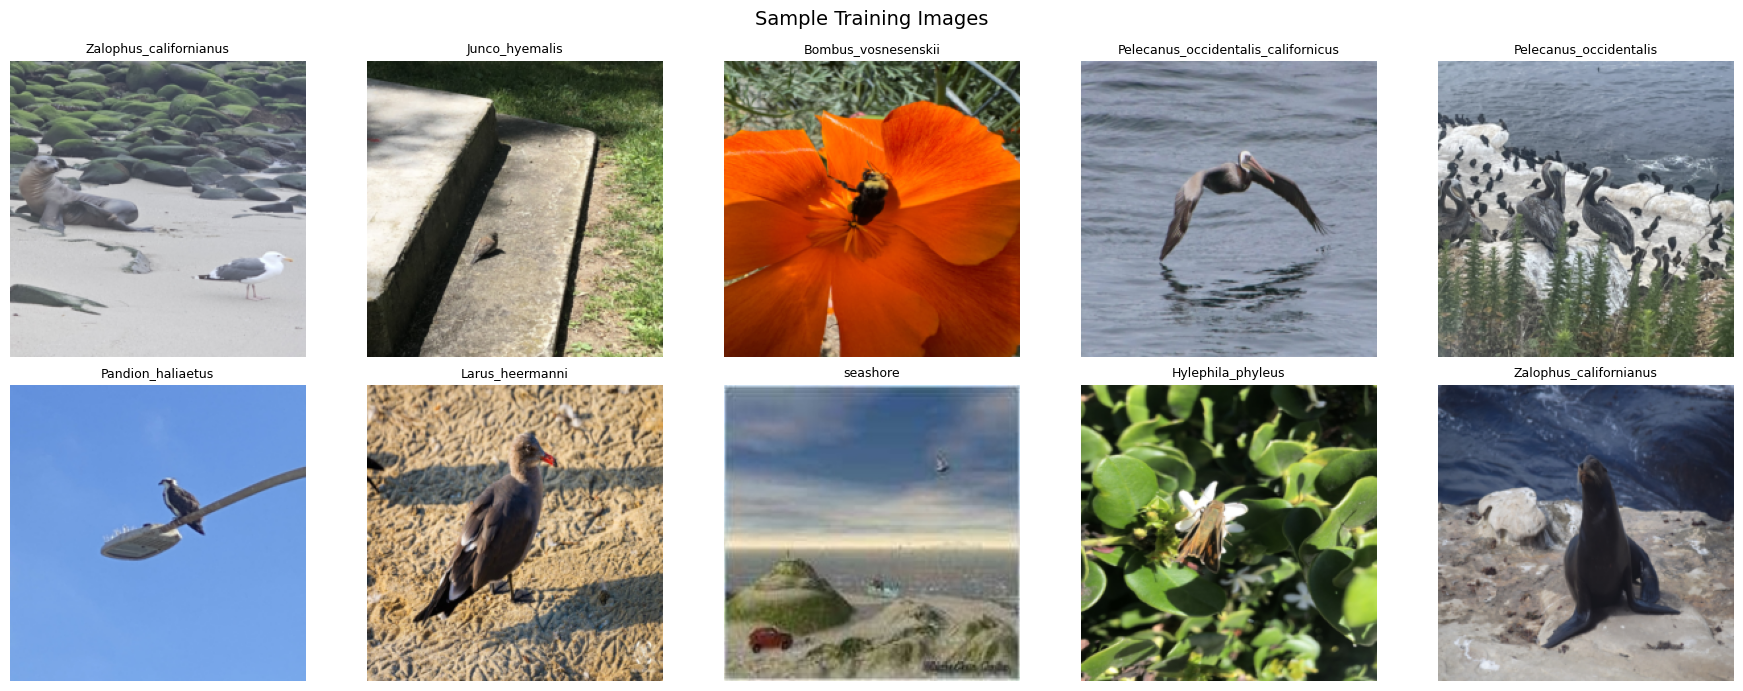

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
indices = random.sample(range(len(train_dataset_raw)), 10)
for ax, idx in zip(axes.flat, indices):
    img, label = train_dataset_raw[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")
fig.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Transforms and DataLoaders

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [6]:
train_dataset = datasets.ImageFolder(DATA_DIR / "train", transform=train_transforms)
val_dataset = datasets.ImageFolder(DATA_DIR / "val", transform=val_test_transforms)
test_dataset = datasets.ImageFolder(DATA_DIR / "test", transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 378
Val batches:   80
Test batches:  84


## 4. Model — float classifier + QAT wrapper (head only)

Order: **backbone → LayerNorm (float) → `QuantStub` → `Linear` (QAT)** — no `DeQuantStub`; the head output stays quantized after `convert`. Training/metrics call `logits_float(outputs)` (`dequantize()` only when needed).

In [7]:
class DINOv2Classifier(nn.Module):
    """DINOv2 backbone + linear classification head."""

    def __init__(self, backbone, embed_dim: int, num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        self.backbone = backbone
        self.backbone_frozen = freeze_backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            self.backbone.eval()
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, x):
        if self.backbone_frozen:
            with torch.no_grad():
                features = self.backbone(x)
        else:
            features = self.backbone(x)
        return self.head(features)


class QATHeadWrapper(nn.Module):
    """Float backbone → LayerNorm (float) → QuantStub → QAT Linear (no DeQuantStub).

    LayerNorm must run on float activations. QuantStub before LayerNorm would produce
    quantized tensors after `convert`, and LayerNorm cannot run on QuantizedCPU.
    After `convert`, logits are quantized; use `logits_float()` for loss/softmax.
    """

    def __init__(self, inner: DINOv2Classifier):
        super().__init__()
        self.backbone = inner.backbone
        self.backbone_frozen = inner.backbone_frozen
        self.quant = torch.ao.quantization.QuantStub()
        self.head = inner.head  # Sequential: [0]=LayerNorm, [1]=Linear

    def forward(self, x):
        if self.backbone_frozen:
            with torch.no_grad():
                features = self.backbone(x)
        else:
            features = self.backbone(x)
        x = self.head[0](features)
        x = self.quant(x)
        x = self.head[1](x)
        return x


def pick_quant_backend() -> str:
    try:
        torch.backends.quantized.engine = "fbgemm"
        return "fbgemm"
    except RuntimeError:
        torch.backends.quantized.engine = "qnnpack"
        return "qnnpack"


def logits_float(outputs):
    """CrossEntropy / softmax need float logits: fake-quant is already float; INT8 uses dequantize()."""
    return outputs.dequantize() if outputs.is_quantized else outputs


def build_qat_model(inner: DINOv2Classifier, device: torch.device):
    """Attach QAT qconfigs and return prepare_qat model on `device`."""
    backend = pick_quant_backend()
    qconfig = torch.ao.quantization.get_default_qat_qconfig(backend)
    wrapped = QATHeadWrapper(inner).to(device)
    wrapped.qconfig = None
    wrapped.backbone.qconfig = None
    wrapped.quant.qconfig = qconfig
    # LayerNorm: float; Linear: fake-quant (avoids eager QAT issues on LayerNorm)
    wrapped.head[0].qconfig = None
    wrapped.head[1].qconfig = qconfig
    model_qat = torch.ao.quantization.prepare_qat(wrapped, inplace=False)
    return model_qat, backend


def load_int8_qat_for_eval(ckpt_path: Path, map_location="cpu"):
    """Rebuild converted INT8 model from `best_model_qat_int8.pth` for eval-only runs."""
    ckpt = torch.load(ckpt_path, map_location=map_location, weights_only=False)
    name = ckpt["model_name"]
    n_cls = ckpt["num_classes"]
    fb = ckpt.get("freeze_backbone", True)
    qeng = ckpt.get("qengine") or pick_quant_backend()
    torch.backends.quantized.engine = qeng
    qconfig = torch.ao.quantization.get_default_qat_qconfig(qeng)
    backbone = torch.hub.load("facebookresearch/dinov2", name)
    inner = DINOv2Classifier(backbone, EMBED_DIMS[name], n_cls, freeze_backbone=fb)
    wrapped = QATHeadWrapper(inner).cpu().train()  # prepare_qat requires training mode
    wrapped.qconfig = None
    wrapped.backbone.qconfig = None
    wrapped.quant.qconfig = qconfig
    wrapped.head[0].qconfig = None
    wrapped.head[1].qconfig = qconfig
    qat = torch.ao.quantization.prepare_qat(wrapped, inplace=False)
    int8_mod = torch.ao.quantization.convert(qat, inplace=False)
    int8_mod.load_state_dict(ckpt["model_state_dict"])
    return int8_mod.eval()


In [8]:
EMBED_DIMS = {"dinov2_vits14": 384, "dinov2_vitb14": 768, "dinov2_vitl14": 1024}

backbone = torch.hub.load("facebookresearch/dinov2", MODEL_NAME)
embed_dim = EMBED_DIMS[MODEL_NAME]

inner = DINOv2Classifier(backbone, embed_dim, num_classes, freeze_backbone=FREEZE_BACKBONE)
model, QENGINE = build_qat_model(inner, DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:>12,}")
print(f"Trainable parameters: {trainable_params:>12,}")
print(f"Q engine:             {QENGINE}")

Using cache found in C:\Users\danie/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\danie/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\danie/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\danie/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


NameError: name 'num_classes' is not defined

## 5. Training Setup

In [23]:
criterion = nn.CrossEntropyLoss()

lr = LEARNING_RATE if FREEZE_BACKBONE else LR_FINETUNE
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=lr, weight_decay=1e-2)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

print(f"Loss:      CrossEntropyLoss")
print(f"Optimizer: AdamW (lr={lr}, wd=1e-2)")
print(f"Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")

Loss:      CrossEntropyLoss
Optimizer: AdamW (lr=0.001, wd=1e-2)
Scheduler: CosineAnnealingLR (T_max=30)


## 6. Training Loop

In [24]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    if FREEZE_BACKBONE:
        model.backbone.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        logits = logits_float(outputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = logits.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_top1 = 0
    correct_top3 = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        logits = logits_float(outputs)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)

        _, preds_top1 = logits.max(1)
        correct_top1 += preds_top1.eq(labels).sum().item()

        _, preds_top3 = logits.topk(min(3, logits.size(1)), dim=1)
        correct_top3 += preds_top3.eq(labels.unsqueeze(1)).any(1).sum().item()

    return running_loss / total, correct_top1 / total, correct_top3 / total

In [11]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [], "val_top3_acc": [],
}

best_val_acc = 0.0
best_model_wts = None
epochs_no_improve = 0

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>10}  {'Train Acc':>10}  {'Val Acc':>10}  {'Val Top3':>10}  {'LR':>10}  {'Time':>6}")
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_top3 = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_top3_acc"].append(val_top3)

    elapsed = time.time() - t0
    current_lr = scheduler.get_last_lr()[0]

    marker = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        marker = " *"
    else:
        epochs_no_improve += 1

    print(f"{epoch:>5d}  {train_loss:>10.4f}  {val_loss:>10.4f}  {train_acc:>10.4f}  {val_acc:>10.4f}  {val_top3:>10.4f}  {current_lr:>10.2e}  {elapsed:>5.1f}s{marker}")

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch  Train Loss    Val Loss   Train Acc     Val Acc    Val Top3          LR    Time
-------------------------------------------------------------------------------------
    1      0.6968      0.2814      0.8546      0.9254      0.9816    9.97e-04  315.0s *
    2      0.2291      0.2437      0.9343      0.9278      0.9831    9.89e-04  335.1s *
    3      0.1594      0.2369      0.9506      0.9341      0.9839    9.76e-04  347.1s *
    4      0.1266      0.2446      0.9616      0.9349      0.9851    9.57e-04  350.8s *
    5      0.1102      0.2295      0.9653      0.9376      0.9839    9.33e-04  349.1s *
    6      0.0981      0.2379      0.9702      0.9349      0.9851    9.05e-04  350.4s
    7      0.0874      0.2314      0.9724      0.9384      0.9855    8.72e-04  346.1s *
    8      0.0762      0.2361      0.9775      0.9372      0.9855    8.35e-04  345.4s
    9      0.0735      0.2418      0.9773      0.9337      0.9859    7.94e-04  339.8s
   10      0.0681      0.2359      0.9788 

### Training curves

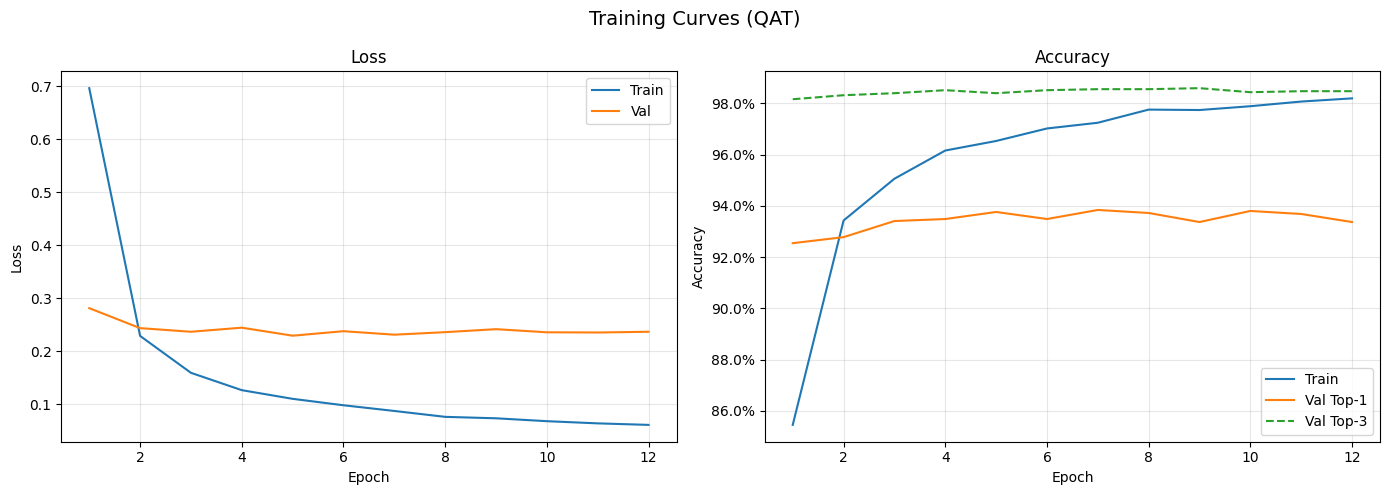

Saved training curves to outputs_qat\training_curves.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs_range, history["train_loss"], label="Train")
ax1.plot(epochs_range, history["val_loss"], label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], label="Train")
ax2.plot(epochs_range, history["val_acc"], label="Val Top-1")
ax2.plot(epochs_range, history["val_top3_acc"], label="Val Top-3", linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

fig.suptitle("Training Curves (QAT)", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved training curves to {OUTPUT_DIR / 'training_curves.png'}")

## 7. Convert QAT → INT8 head and evaluate

Load best fake-quant weights, move to **CPU**, set the quantized engine, `convert`, then run test metrics (INT8 path is evaluated on CPU).

**Note:** If you trained with an older notebook that ran `QuantStub` *before* `LayerNorm`, retrain once so checkpoints match the corrected graph (LN → quant → Linear).

In [25]:
model.load_state_dict(best_model_wts)
model.eval()

torch.backends.quantized.engine = QENGINE
model_cpu = model.cpu()
model_int8 = torch.ao.quantization.convert(model_cpu, inplace=False)
model_int8.eval()

_cpu = torch.device("cpu")
# If you only have a saved checkpoint (no in-memory training), use:
# model_int8 = load_int8_qat_for_eval(OUTPUT_DIR / "best_model_qat_int8.pth")
test_loss, test_top1, test_top3 = evaluate(model_int8, test_loader, criterion, _cpu)
print(f"Test Loss (INT8 head):      {test_loss:.4f}")
print(f"Test Top-1 Acc (INT8 head): {test_top1:.4f}")
print(f"Test Top-3 Acc (INT8 head): {test_top3:.4f}")

Test Loss (INT8 head):      0.2689
Test Top-1 Acc (INT8 head): 0.9235
Test Top-3 Acc (INT8 head): 0.9828


### Classification report and confusion matrix (INT8)

In [26]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    all_labels = []
    all_preds = []
    all_probs = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        logits = logits_float(outputs)
        probs = torch.softmax(logits, dim=1)
        all_labels.append(labels)
        all_preds.append(logits.argmax(1).cpu())
        all_probs.append(probs.cpu())

    return (torch.cat(all_labels).numpy(),
            torch.cat(all_preds).numpy(),
            torch.cat(all_probs).numpy())


y_true, y_pred, y_probs = collect_predictions(model_int8, test_loader, _cpu)

print("Classification Report (INT8 head):\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

KeyboardInterrupt: 

In [15]:
cm = confusion_matrix(y_true, y_pred)

fig_size = max(10, num_classes * 0.4)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

sns.heatmap(cm, annot=num_classes <= 30, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix — Test Set (QAT INT8 head)", fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()

if num_classes >= 3:
    sk_top3 = top_k_accuracy_score(y_true, y_probs, k=3, labels=range(num_classes))
    print(f"sklearn top-3 accuracy (verification): {sk_top3:.4f}")

NameError: name 'y_true' is not defined

## 8. Prediction on a Single Image (INT8 head)

In [16]:
@torch.no_grad()
def predict_single_image(image_path, model, transform, class_names, device, top_k=3):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    model.eval()
    logits = model(img_tensor)
    probs = torch.softmax(logits_float(logits), dim=1).squeeze(0)
    top_probs, top_indices = probs.topk(top_k)
    results = [(class_names[idx], prob.item()) for idx, prob in zip(top_indices, top_probs)]
    return img, results


sample_path, sample_label = test_dataset.samples[random.randint(0, len(test_dataset) - 1)]
true_name = class_names[sample_label]

img, predictions = predict_single_image(sample_path, model_int8, val_test_transforms, class_names, _cpu, top_k=3)

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.5]})

ax_img.imshow(img)
ax_img.set_title(f"True: {true_name}", fontsize=12)
ax_img.axis("off")

names = [p[0] for p in predictions]
probs = [p[1] for p in predictions]
colors = ["#2ecc71" if n == true_name else "#3498db" for n in names]
ax_bar.barh(range(len(names)), probs, color=colors)
ax_bar.set_yticks(range(len(names)))
ax_bar.set_yticklabels(names, fontsize=10)
ax_bar.set_xlabel("Probability")
ax_bar.set_title("Top-3 Predictions (INT8)")
ax_bar.set_xlim(0, 1)
ax_bar.invert_yaxis()

plt.tight_layout()
plt.show()

for rank, (name, prob) in enumerate(predictions, 1):
    print(f"  #{rank}: {name:<30s} {prob:.4f}")

NotImplementedError: Could not run 'aten::native_batch_norm' with arguments from the 'QuantizedCPU' backend. This could be because the operator doesn't exist for this backend, or was omitted during the selective/custom build process (if using custom build). If you are a Facebook employee using PyTorch on mobile, please visit https://fburl.com/ptmfixes for possible resolutions. 'aten::native_batch_norm' is only available for these backends: [CPU, CUDA, Meta, MkldnnCPU, BackendSelect, Python, FuncTorchDynamicLayerBackMode, Functionalize, Named, Conjugate, Negative, ZeroTensor, ADInplaceOrView, AutogradOther, AutogradCPU, AutogradCUDA, AutogradHIP, AutogradXLA, AutogradMPS, AutogradIPU, AutogradXPU, AutogradHPU, AutogradVE, AutogradLazy, AutogradMTIA, AutogradPrivateUse1, AutogradPrivateUse2, AutogradPrivateUse3, AutogradMeta, AutogradNestedTensor, Tracer, AutocastCPU, AutocastXPU, AutocastMPS, AutocastCUDA, FuncTorchBatched, BatchedNestedTensor, FuncTorchVmapMode, Batched, VmapMode, Func

## 9. Saving Artifacts

- `best_model_qat_int8.pth` — converted INT8 head + metadata (for quantized inference).
- `best_model_qat_prepared.pth` — optional: best **fake-quant** state before `convert` (resume / debugging).
- `class_names.json`, `metrics.json`, plots in `outputs_qat/`.

The TourGuide agent loads **float** `best_model.pth` from the baseline notebook; this run is optimized for **INT8 head** deployment parity with the PTQ cell.

In [27]:
lr = LEARNING_RATE if FREEZE_BACKBONE else LR_FINETUNE

int8_path = OUTPUT_DIR / "best_model_qat_int8.pth"
torch.save({
    "model_state_dict": model_int8.state_dict(),
    "model_name": MODEL_NAME,
    "num_classes": num_classes,
    "class_names": class_names,
    "image_size": IMAGE_SIZE,
    "freeze_backbone": FREEZE_BACKBONE,
    "best_val_acc": best_val_acc,
    "quantization": "qat_int8_head",
    "qengine": QENGINE,
}, int8_path)
print(f"Saved INT8 QAT checkpoint: {int8_path}")

prepared_path = OUTPUT_DIR / "best_model_qat_prepared.pth"
torch.save({
    "model_state_dict": best_model_wts,
    "model_name": MODEL_NAME,
    "num_classes": num_classes,
    "class_names": class_names,
    "image_size": IMAGE_SIZE,
    "freeze_backbone": FREEZE_BACKBONE,
    "best_val_acc": best_val_acc,
    "quantization": "qat_fake_quant_head",
    "qengine": QENGINE,
}, prepared_path)
print(f"Saved fake-quant checkpoint: {prepared_path}")

class_names_path = OUTPUT_DIR / "class_names.json"
with open(class_names_path, "w") as f:
    json.dump(class_names, f, indent=2)
print(f"Saved class names: {class_names_path}")

metrics = {
    "best_val_acc": best_val_acc,
    "test_top1_acc": test_top1,
    "test_top3_acc": test_top3,
    "test_loss": test_loss,
    "num_epochs_trained": len(history["train_loss"]),
    "model_name": MODEL_NAME,
    "freeze_backbone": FREEZE_BACKBONE,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": lr,
    "quantization": "qat_int8_head",
    "qengine": QENGINE,
    "history": history,
}
metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Saved metrics: {metrics_path}")
print("\nAll artifacts saved under", OUTPUT_DIR.resolve())

Saved INT8 QAT checkpoint: outputs_qat\best_model_qat_int8.pth
Saved fake-quant checkpoint: outputs_qat\best_model_qat_prepared.pth
Saved class names: outputs_qat\class_names.json
Saved metrics: outputs_qat\metrics.json

All artifacts saved under C:\Users\danie\Documents\1_Productivity\1_Datahacks2026\species_identification\outputs_qat


## 10. INT8 TFLite (`outputs_qat/tflite_int8/model_int8.tflite`)

**`best_model_qat_int8.pth`** is not converted to TFLite directly. This step exports **float ONNX** from the same QAT weights (`best_model_qat_prepared.pth` or `best_model_wts`), then runs **`export_int8_tflite_subprocess.py`**: onnx2tf **`_full_integer_quant.tflite`** (renamed to `model_int8.tflite`). BatchMatMul **unfold** is enabled by default for attention (disable with env `ONNX2TF_NO_BATCHMATMUL_UNFOLD=1` if needed).

**Checking true int8 (no unquantized float weights):** after export, run  
`python verify_tflite_full_integer.py outputs_qat/tflite_int8/model_int8.tflite --strict`  
DINOv2 ViT ONNX often still contains **float MatMul/Conv** in TFLite even with “full_integer” in the filename — those ops need an FPU. For a **fully int8** edge model, train **`qat_efficientnet_lite.ipynb`** instead (EfficientNet-Lite + TF integer pipeline).

Requires: `pip install onnx onnx2tf tensorflow`.

In [11]:
import subprocess
import sys

int8_ckpt = OUTPUT_DIR / "best_model_qat_int8.pth"
if not int8_ckpt.is_file():
    raise FileNotFoundError(
        f"Expected {int8_ckpt} — train and save QAT checkpoints first."
    )

prepared_fp = OUTPUT_DIR / "best_model_qat_prepared.pth"
img_sz = IMAGE_SIZE
meta_model_name = MODEL_NAME
meta_num_classes = num_classes
meta_freeze = FREEZE_BACKBONE
state_for_export = None

if prepared_fp.is_file():
    _ck = torch.load(prepared_fp, map_location="cpu", weights_only=False)
    state_for_export = _ck["model_state_dict"]
    meta_model_name = _ck["model_name"]
    meta_num_classes = _ck["num_classes"]
    meta_freeze = _ck.get("freeze_backbone", True)
    img_sz = _ck.get("image_size", IMAGE_SIZE)
elif "best_model_wts" in globals() and best_model_wts is not None:
    state_for_export = best_model_wts
else:
    raise FileNotFoundError(
        "Need outputs_qat/best_model_qat_prepared.pth or in-memory best_model_wts. "
        "ONNX export uses float tensors from the same QAT run as best_model_qat_int8.pth."
    )

float_export = DINOv2Classifier(
    torch.hub.load("facebookresearch/dinov2", meta_model_name),
    EMBED_DIMS[meta_model_name],
    meta_num_classes,
    freeze_backbone=meta_freeze,
).cpu().eval()
float_sd = float_export.state_dict()
for k, v in state_for_export.items():
    if k in float_sd and float_sd[k].shape == v.shape:
        float_sd[k] = v
float_export.load_state_dict(float_sd)

onnx_path = OUTPUT_DIR / "model.onnx"
dummy = torch.randn(1, 3, img_sz, img_sz)
torch.onnx.export(
    float_export,
    dummy,
    onnx_path,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17,
    do_constant_folding=True,
)
print(f"Exported ONNX: {onnx_path}")

# onnx2tf calibration: NHWC float32 in [0,1] (library applies ImageNet mean/std)
if "val_loader" not in globals():
    raise RuntimeError("Need val_loader from the data section.")

_mean = np.array(IMAGENET_MEAN, dtype=np.float32).reshape(1, 3, 1, 1)
_std = np.array(IMAGENET_STD, dtype=np.float32).reshape(1, 3, 1, 1)
calib_list = []
n = 0
for images, _ in val_loader:
    x = images.cpu().numpy()
    x01 = np.clip(x * _std + _mean, 0.0, 1.0)
    x_hwc = np.transpose(x01, (0, 2, 3, 1))
    for i in range(x_hwc.shape[0]):
        calib_list.append(x_hwc[i : i + 1])
        n += 1
        if n >= 100:
            break
    if n >= 100:
        break
if not calib_list:
    raise RuntimeError("No calibration batches from val_loader")
calib_npy = OUTPUT_DIR / "_int8_calib_nhwc.npy"
np.save(calib_npy, np.concatenate(calib_list, axis=0).astype(np.float32))
print(f"Saved calibration array: {calib_npy} shape {np.load(calib_npy).shape}")


def _find_int8_script() -> Path:
    for root in (Path.cwd(), Path.cwd() / "species_identification"):
        p = root / "export_int8_tflite_subprocess.py"
        if p.is_file():
            return p.resolve()
    raise FileNotFoundError("export_int8_tflite_subprocess.py not found.")


out_tflite_dir = OUTPUT_DIR / "tflite_int8"
out_tflite_dir.mkdir(parents=True, exist_ok=True)
_script = _find_int8_script()
subprocess.check_call(
    [
        sys.executable,
        str(_script),
        str(onnx_path.resolve()),
        str(out_tflite_dir.resolve()),
        str(calib_npy.resolve()),
        "input",
    ]
)
print(f"INT8 TFLite: {(out_tflite_dir / 'model_int8.tflite').resolve()}")

_vrf = _script.parent / "verify_tflite_full_integer.py"
if _vrf.is_file():
    print("Verifying integer TFLite (no unquantized float tensors; --strict fails if any remain):")
    subprocess.run(
        [sys.executable, str(_vrf), str((out_tflite_dir / "model_int8.tflite").resolve()), "--strict"],
        check=False,
    )

Using cache found in C:\Users\danie/.cache\torch\hub\facebookresearch_dinov2_main


Exported ONNX: outputs_qat\model.onnx
Saved calibration array: outputs_qat\_int8_calib_nhwc.npy shape (100, 224, 224, 3)
INT8 TFLite: C:\Users\danie\Documents\1_Productivity\1_Datahacks2026\species_identification\outputs_qat\tflite_int8\model_int8.tflite
